# ${}^{4}{\rm He}$

The interaction is defined in `helium4plusplus.py`. It is nonlocal, and so is the counterterm. 

We will use it to non-perturbatviely calculate NLO phase shifts.

In [12]:
import numpy as np
from scipy import optimize
import matplotlib.pyplot as plt
import scienceplots
from tqdm import tqdm

import mu2

import helium4plusplus as he4

plt.style.use('science')

In [13]:
ELL = 0

# rg_flow = np.loadtxt('datfiles/rgflow_gLO_gNLO_perturbative_nonlocal_2_6_6.dat')
rg_flow = np.loadtxt('datfiles/rg_flows/nonlocal_nlo_np.txt')

In [34]:
# momenta = np.linspace(0.01/he4.BETA6, 10/he4.BETA6, 100)
momenta = np.loadtxt('datfiles/phase_shifts/momenta.txt')

In [35]:
R, glo, gnlo = rg_flow[0]
s = he4.NonlocalHelium4System2(R, ELL, 2, 6, 6, nq=200)

In [36]:
s.a0_and_r0(glo, gnlo, momenta, use_c=True)

(-1.0, 2.0)

In [37]:
phase_shifts = []

for (R, glo, gnlo) in tqdm(rg_flow):
    s = he4.NonlocalHelium4System2(R, ELL, 2, 6, 6, nq=200)
    kcd = s.kcotd_gen_fast(momenta, glo, gnlo)
    phase_shifts.append(np.arctan(momenta/kcd))

100%|███████████████████████████████████████████| 51/51 [01:51<00:00,  2.19s/it]


In [38]:
phase_shifts = np.array(phase_shifts)

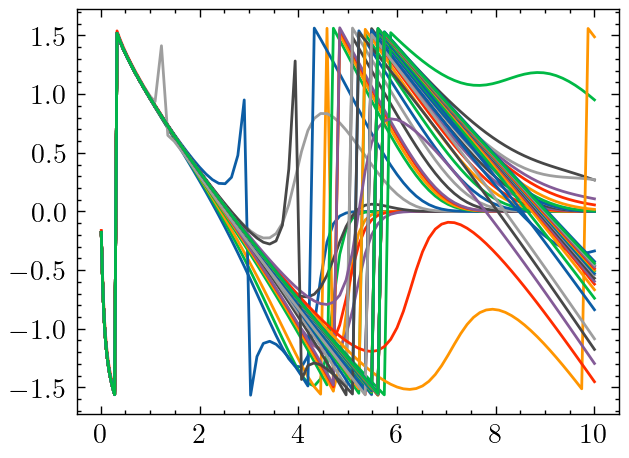

In [39]:
fig, ax = plt.subplots(dpi=200)
fig.patch.set_facecolor('white')

ax.plot(momenta*he4.BETA6, phase_shifts.T);

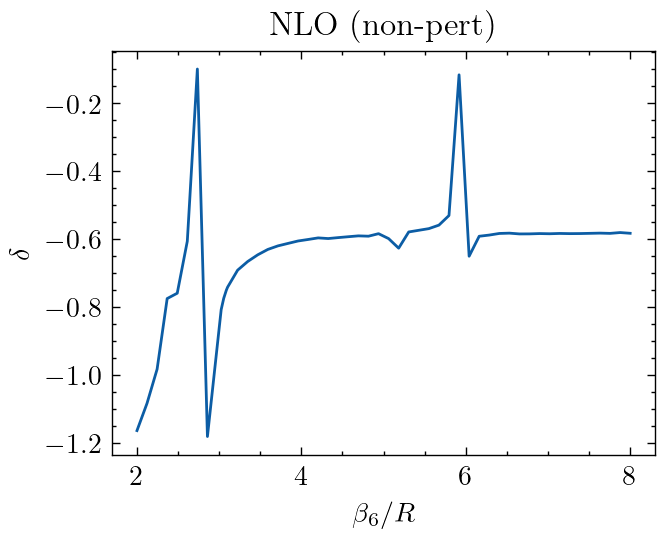

In [40]:
index = 50

fig, ax = plt.subplots(dpi=200)
fig.patch.set_facecolor('white')

ax.plot(he4.BETA6/rg_flow[:, 0], phase_shifts[:, index])

ax.set_xlabel(r'$\beta_6/R$')
ax.set_ylabel(r'$\delta$')
ax.set_title('NLO (non-pert)');

In [41]:
phase_shifts.shape

(51, 100)

In [42]:
np.savetxt('datfiles/phase_shifts/nonlocal_nlo_np.txt', np.vstack((momenta, phase_shifts)).T)